In [1]:
library(lidR)
set_lidr_threads(14)
library(terra)
library(sf)
library(data.table)

terra 1.9.34


Attaching package: ‘terra’


The following object is masked from ‘package:lidR’:

    watershed


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE


Attaching package: ‘sf’


The following object is masked from ‘package:lidR’:

    st_concave_hull



Attaching package: ‘data.table’


The following object is masked from ‘package:terra’:

    shift




class       : SpatRaster
size        : 3155, 1631, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 148005, 196935, 6825, 101475  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 37N (EPSG:32637)
source(s)   : memory
varname     : EnMAP_15_02_2026_1
name        : Band 1
min value   :   -714
max value   :  29545


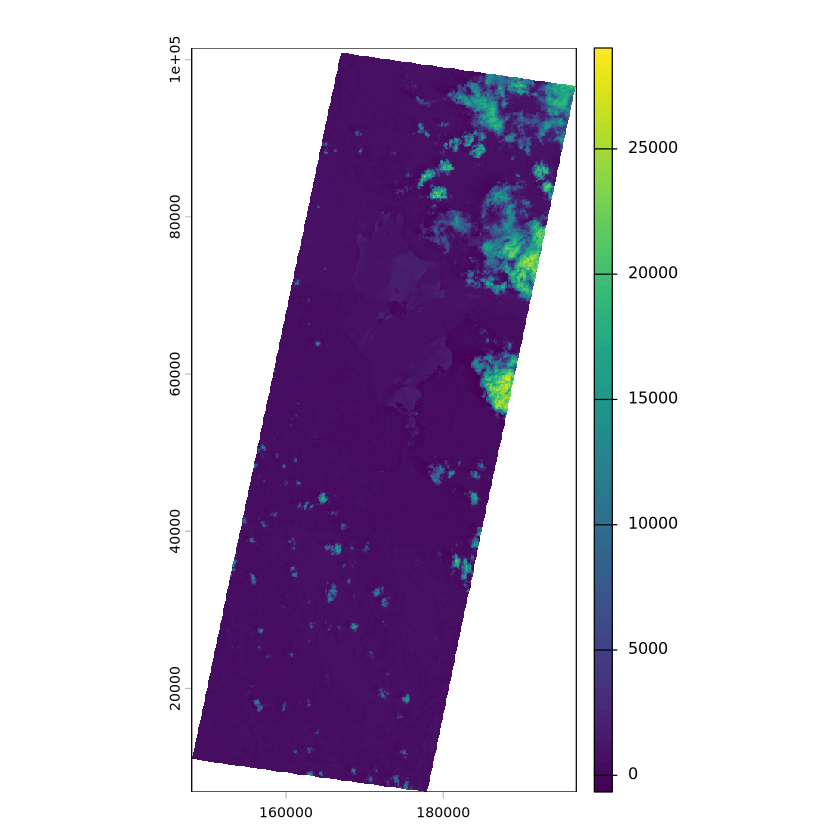

In [2]:
# =========================================================
# ENMAP INPUT
# =========================================================


enmap_dir <- "EnMAP_bsqs"

enmap_hdr <- list.files(
  enmap_dir,
  pattern = "\\.bsq$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (length(enmap_hdr) != 3) {
  stop("Es müssen genau drei EnMAP BSQ-Dateien vorhanden sein.")
}

enmap_tiles <- lapply(
  enmap_hdr,
  terra::rast
)

# Nur erstes Band als räumliches Template
enmap_grid <- lapply(
  enmap_tiles,
  function(x) x[[1]]
)

# Mosaik des EnMAP-Grids
enmap_grid <- do.call(
  terra::mosaic,
  c(enmap_grid, fun = "mean")
)

print(enmap_grid)

plot(enmap_grid)

# Per Pixel with new canopy heigth model

In [3]:
library(sf)
library(terra)
library(lidR)
library(data.table)

# =========================================================
# PARAMETERS
# =========================================================
input_dir  <- "01_data"
out_root   <- "02_output/EnMAP_pixel_metrics_LAS" 
plots_path <- "01_data/Baringo_Sites_updated.geojson"
# Site18/Tree-Level_Metrics/
crs_epsg      <- 21097
target_crs    <- sf::st_crs(crs_epsg)$wkt
res_dtm       <- 0.5
min_tree_h    <- 0.5
min_points_gt <- 5
min_cover     <- 0.995

dir.create(out_root, recursive = TRUE, showWarnings = FALSE)

# =========================================================
# LOAD PLOTS
# =========================================================
plots <- st_read(plots_path, quiet = TRUE) |>
  st_make_valid()

st_crs(plots) <- crs_epsg
plots <- st_transform(plots, crs_epsg)
plots$plot_row <- seq_len(nrow(plots))

# =========================================================
# ENMAP TEMPLATE
# =========================================================
# enmap_grid muss vorher aus deinen BSQ-Dateien erstellt worden sein.
# Wichtig: NICHT als Raster nach EPSG:21097 reprojizieren.
enmap_ref <- enmap_grid
names(enmap_ref) <- "EnMAP"

# =========================================================
# CHOOSE PLOT BY LAS CENTROID
# =========================================================
# =========================================================
# CHOOSE PLOT BY LAS CENTROID
# =========================================================
choose_plot_by_centroid <- function(las, plots_sf) {

  x <- las@data$X
  y <- las@data$Y

  bb <- c(
    xmin = min(x, na.rm = TRUE),
    xmax = max(x, na.rm = TRUE),
    ymin = min(y, na.rm = TRUE),
    ymax = max(y, na.rm = TRUE)
  )

  ctr <- st_sfc(
    st_point(
      c(
        (bb["xmin"] + bb["xmax"]) / 2,
        (bb["ymin"] + bb["ymax"]) / 2
      )
    ),
    crs = st_crs(plots_sf)
  )

  contains_list <- st_contains(
    plots_sf,
    ctr,
    sparse = TRUE
  )

  hit <- which(lengths(contains_list) > 0)

  if (length(hit) >= 1) {
    return(hit[1])
  }

  st_nearest_feature(ctr, plots_sf)
}

# =========================================================
# ENMAP PIXELS FROM ORIGINAL GRID
# =========================================================
pixel_polygons_full_in_site <- function(enmap_original, site_sf, min_cover = 0.995) {

  site_enmap_crs <- st_transform(site_sf, crs = terra::crs(enmap_original))
  site_vect <- terra::vect(site_enmap_crs)

  enmap_crop <- terra::crop(enmap_original, terra::ext(site_vect))
  enmap_crop <- terra::setValues(enmap_crop, 1)

  pix <- terra::as.polygons(
    enmap_crop,
    dissolve = FALSE,
    values = FALSE,
    na.rm = FALSE
  )

  pix_sf <- st_as_sf(pix)
  pix_sf$pixel_id <- seq_len(nrow(pix_sf))

  # Pixelpolygone nach LAS-/Site-CRS
  pix_21097 <- st_transform(pix_sf, crs = st_crs(site_sf))
  pix_21097 <- st_make_valid(pix_21097)

  site_sf <- st_make_valid(site_sf)

  cand_idx <- which(st_intersects(pix_21097, site_sf, sparse = FALSE)[, 1])

  if (!length(cand_idx)) {
    return(pix_21097[0, , drop = FALSE])
  }

  cand <- pix_21097[cand_idx, , drop = FALSE]
  cand$pixel_area <- as.numeric(st_area(cand))

  inter <- suppressWarnings(st_intersection(cand, site_sf))

  if (!nrow(inter)) {
    return(pix_21097[0, , drop = FALSE])
  }

  inter$inter_area <- as.numeric(st_area(inter))

  area_dt <- as.data.table(st_drop_geometry(inter))[
    ,
    .(inter_area = sum(inter_area, na.rm = TRUE)),
    by = pixel_id
  ]

  cand_dt <- data.table(
    pixel_id = cand$pixel_id,
    pixel_area = cand$pixel_area
  )

  cover_dt <- merge(cand_dt, area_dt, by = "pixel_id", all.x = TRUE)
  cover_dt[is.na(inter_area), inter_area := 0]
  cover_dt[, coverage_ratio := inter_area / pixel_area]

  cand$coverage_ratio <- cover_dt$coverage_ratio[
    match(cand$pixel_id, cover_dt$pixel_id)
  ]

  cand[cand$coverage_ratio >= min_cover, , drop = FALSE]
}

# =========================================================
# METRICS FROM NORMALIZED LAS Z
# =========================================================
pixel_las_metrics_fun <- function(z) {

  z <- suppressWarnings(as.numeric(z))
  z <- z[is.finite(z) & z >= 0]

  if (!length(z)) {
    return(list(
      n_points = 0L,
      H25 = NA_real_,
      H50 = NA_real_,
      H75 = NA_real_,
      H95 = NA_real_,
      Hmean = NA_real_,
      Hmax = NA_real_,
      CC0.5m = NA_real_,
      CCmean = NA_real_,
      GapFraction_0.5m = NA_real_
    ))
  }

  # Canopy cover aus allen gültigen normalisierten Punkten
  CC0.5m <- mean(z > min_tree_h)
  GapFraction_0.5m <- 1 - CC0.5m

  zmean_all <- mean(z)
  CCmean <- mean(z > zmean_all)

  # Height metrics nur für Vegetationspunkte > 2 m
  zh <- z[z > min_tree_h]

  if (length(zh) < min_points_gt) {
    H25 <- H50 <- H75 <- H95 <- Hmean <- Hmax <- NA_real_
  } else {
    qs <- quantile(
      zh,
      probs = c(0.25, 0.50, 0.75, 0.95),
      na.rm = TRUE,
      names = FALSE
    )

    H25 <- qs[1]
    H50 <- qs[2]
    H75 <- qs[3]
    H95 <- qs[4]
    Hmean <- mean(zh)
    Hmax <- max(zh)
  }

  list(
    n_points = length(z),
    H25 = round(H25, 4),
    H50 = round(H50, 4),
    H75 = round(H75, 4),
    H95 = round(H95, 4),
    Hmean = round(Hmean, 4),
    Hmax = round(Hmax, 4),
    CC0.5m = round(CC0.5m, 4),
    CCmean = round(CCmean, 4),
    GapFraction_0.5m = round(GapFraction_0.5m, 4)
  )
}

# =========================================================
# PROCESS ONE LAS FILE
# =========================================================
process_one_las_file <- function(fpath) {

  message("\n=== Processing: ", basename(fpath), " ===")

  las <- readLAS(fpath)

  if (lidR::is.empty(las)) {
    warning("Empty LAS: ", basename(fpath))
    return(NULL)
  }

  projection(las) <- target_crs

  las@data$Z <- suppressWarnings(as.numeric(las@data$Z))
  las@data$Z[!is.finite(las@data$Z)] <- NA_real_

  # -------------------------------------------------------
  # Match and clip to Site polygon
  # -------------------------------------------------------
  j <- choose_plot_by_centroid(las, plots)
  site_sf <- plots[j, , drop = FALSE]

  las_site <- tryCatch(
    {
      lidR::clip_roi(las, site_sf)
    },
    error = function(e) {
      warning("clip_roi failed for ", basename(fpath), ": ", e$message)
      return(NULL)
    }
  )

  if (is.null(las_site) || lidR::is.empty(las_site)) {
    warning("No points inside site polygon: ", basename(fpath))
    return(NULL)
  }

  # -------------------------------------------------------
  # DTM + normalize height
  # -------------------------------------------------------
  dtm <- rasterize_terrain(
    las_site,
    algorithm = knnidw(k = 10, p = 2),
    res = res_dtm
  )

  terra::crs(dtm) <- target_crs

  las_norm <- normalize_height(las_site, dtm)

  # Wichtig: NICHT auf Z >= min_tree_h filtern,
  # sonst werden Canopy Cover und Gap Fraction verzerrt.
  las_norm <- filter_poi(las_norm, Z >= 0)

  if (lidR::is.empty(las_norm)) {
    warning("No normalized points remaining: ", basename(fpath))
    return(NULL)
  }

  # -------------------------------------------------------
  # Get full EnMAP pixels inside site
  # -------------------------------------------------------
  pix_pol <- pixel_polygons_full_in_site(
    enmap_original = enmap_ref,
    site_sf = site_sf,
    min_cover = min_cover
  )

  message("  Full EnMAP pixels: ", nrow(pix_pol))

  if (!nrow(pix_pol)) {
    warning("No full EnMAP pixels in site: ", basename(fpath))
    return(NULL)
  }

  cent <- st_centroid(pix_pol$geometry)
  cent_xy <- st_coordinates(cent)

  # -------------------------------------------------------
  # Metrics per EnMAP pixel from LAS points
  # -------------------------------------------------------
  out_list <- vector("list", nrow(pix_pol))

  for (k in seq_len(nrow(pix_pol))) {

    las_pix <- tryCatch(
      {
        lidR::clip_roi(las_norm, pix_pol[k, ])
      },
      error = function(e) {
        NULL
      }
    )

    if (is.null(las_pix) || lidR::is.empty(las_pix)) {
      m <- pixel_las_metrics_fun(numeric(0))
    } else {
      m <- pixel_las_metrics_fun(las_pix@data$Z)
    }

    out_list[[k]] <- data.table(
      pixel_id = pix_pol$pixel_id[k],
      x_center = cent_xy[k, 1],
      y_center = cent_xy[k, 2],
      coverage_ratio = round(pix_pol$coverage_ratio[k], 6),
      n_points = m$n_points,
      H25 = m$H25,
      H50 = m$H50,
      H75 = m$H75,
      H95 = m$H95,
      Hmean = m$Hmean,
      Hmax = m$Hmax,
      CC0.5m = m$CC0.5m,
      CCmean = m$CCmean,
      GapFraction_0.5m = m$GapFraction_0.5m
    )
  }

  res <- rbindlist(out_list, fill = TRUE)

  stem <- tools::file_path_sans_ext(basename(fpath))
  site_id <- sub(".*site\\s*([0-9]+).*", "\\1", stem, ignore.case = TRUE)

  if (!nzchar(site_id)) {
    site_id <- paste0("plotrow_", j)
  }

  res[, Site := site_id]
  setcolorder(res, c("Site", setdiff(names(res), "Site")))

  out_dir_site <- file.path(out_root, paste0("Site_", site_id))
  dir.create(out_dir_site, recursive = TRUE, showWarnings = FALSE)

  out_csv <- file.path(
    out_dir_site,
    paste0("enmap_pixel_metrics_from_LAS_", stem, ".csv")
  )

  fwrite(res, out_csv)

  message("Wrote: ", out_csv)

  invisible(res)
}

# =========================================================
# BATCH PROCESSING
# =========================================================
files <- list.files(
  input_dir,
  pattern = "\\.(las|laz)$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (!length(files)) {
  stop("No LAS/LAZ files found in: ", input_dir)
}

for (f in files) {
  try(process_one_las_file(f), silent = FALSE)
}


=== Processing: site 1.laz ===



                                                                                48s     

  Full EnMAP pixels: 4

Wrote: 02_output/EnMAP_pixel_metrics_LAS/Site_1/enmap_pixel_metrics_from_LAS_site 1.csv


=== Processing: site 10.laz ===



                                                                                48s     

  Full EnMAP pixels: 6

Wrote: 02_output/EnMAP_pixel_metrics_LAS/Site_10/enmap_pixel_metrics_from_LAS_site 10.csv


=== Processing: site 13.laz ===



...

  Full EnMAP pixels: 6

Wrote: 02_output/EnMAP_pixel_metrics_LAS/Site_3/enmap_pixel_metrics_from_LAS_site 3.csv


=== Processing: site 3.laz ===



Error in eval(expr, envir) :                                                    48s     
  Non quantizable value outside the range of representable values of type 'int'



=== Processing: site 4.laz ===



                                                                                48s     

  Full EnMAP pixels: 6

Wrote: 02_output/EnMAP_pixel_metrics_LAS/Site_4/enmap_pixel_metrics_from_LAS_site 4.csv



# Old Approach wtih the already computed CHM

In [11]:
library(sf)
library(terra)
library(data.table)

# =========================================================
# PARAMETERS
# =========================================================
crs_epsg <- 21097
min_tree_h <- 2.0

plots_path <- "01_data/Baringo_Sites_updated.geojson"
chm_dir <- "Site21/Tree-Level_Metrics"
out_root <- "02_output/EnMAP_pixel_metrics"
# Site18/Tree-Level_Metrics
dir.create(out_root, recursive = TRUE, showWarnings = FALSE)

# =========================================================
# LOAD PLOTS
# =========================================================
plots <- st_read(plots_path, quiet = TRUE) |>
  st_make_valid()

st_crs(plots) <- crs_epsg
plots <- st_transform(plots, crs_epsg)

plots$plot_row <- seq_len(nrow(plots))

# =========================================================
# ENMAP TEMPLATE
# =========================================================
enmap_ref <- enmap_grid
names(enmap_ref) <- "EnMAP"

# Kontrolle
print(enmap_ref)
print(terra::crs(enmap_ref, proj = TRUE))

# =========================================================
# CHM FILES
# =========================================================
chm_files <- list.files(
  chm_dir,
  pattern = "^CHM_.*\\.tif$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (!length(chm_files)) {
  stop("Keine CHM-Dateien gefunden in: ", chm_dir)
}

# Site-ID from filename, z.B. "CHM_site 18_fixed_epsg21097.tif" -> 18
get_site_id <- function(fn) {
  b <- basename(fn)

  m <- regmatches(
    b,
    regexpr("(?i)site\\s*[_-]*\\s*[0-9]+", b, perl = TRUE)
  )

  if (length(m) == 0 || is.na(m)) {
    return(tools::file_path_sans_ext(b))
  }

  as.integer(gsub("[^0-9]", "", m))
}

# =========================================================
# CHOOSE PLOT BY CHM CENTROID
# =========================================================
choose_plot_by_chm_centroid <- function(chm, plots_sf) {

  e <- terra::ext(chm)

  ctr <- st_sfc(
    st_point(
      c(
        (e$xmin + e$xmax) / 2,
        (e$ymin + e$ymax) / 2
      )
    ),
    crs = st_crs(plots_sf)
  )

  contains_list <- st_contains(
    plots_sf,
    ctr,
    sparse = TRUE
  )

  hit <- which(lengths(contains_list) > 0)

  if (length(hit) >= 1) {
    return(hit[1])
  }

  st_nearest_feature(ctr, plots_sf)
}

# =========================================================
# FULL ENMAP PIXELS INSIDE SITE
# Pixel werden im ORIGINAL-EnMAP-Grid erzeugt,
# dann nach EPSG:21097 transformiert
# =========================================================
pixel_polygons_full_in_site <- function(enmap_original, site_sf, min_cover = 0.995) {

  # Site nur zum Croppen in originales EnMAP-CRS transformieren
  site_enmap_crs <- st_transform(site_sf, crs = terra::crs(enmap_original))
  site_vect <- terra::vect(site_enmap_crs)

  # EnMAP im Originalgrid auf Site-Extent croppen
  enmap_crop <- terra::crop(enmap_original, terra::ext(site_vect))

  # Alle Zellen mit Wert belegen, damit as.polygons alle Pixel erzeugt
  enmap_crop <- terra::setValues(enmap_crop, 1)

  pix <- terra::as.polygons(
    enmap_crop,
    dissolve = FALSE,
    values = FALSE,
    na.rm = FALSE
  )

  pix_sf <- st_as_sf(pix)
  pix_sf$pixel_id <- seq_len(nrow(pix_sf))

  # Pixelpolygone nach Site-/CHM-CRS transformieren
  pix_21097 <- st_transform(pix_sf, crs = st_crs(site_sf))
  pix_21097 <- st_make_valid(pix_21097)

  site_sf <- st_make_valid(site_sf)

  # Kandidaten, die Site schneiden
  cand_idx <- which(
    st_intersects(pix_21097, site_sf, sparse = FALSE)[, 1]
  )

  if (!length(cand_idx)) {
    return(pix_21097[0, , drop = FALSE])
  }

  cand <- pix_21097[cand_idx, , drop = FALSE]
  cand$pixel_area <- as.numeric(st_area(cand))

  # Überlappungsfläche berechnen
  inter <- suppressWarnings(
    st_intersection(cand, site_sf)
  )

  if (!nrow(inter)) {
    return(pix_21097[0, , drop = FALSE])
  }

  inter$inter_area <- as.numeric(st_area(inter))

  area_dt <- data.table::as.data.table(st_drop_geometry(inter))[
    ,
    .(inter_area = sum(inter_area, na.rm = TRUE)),
    by = pixel_id
  ]

  cand_dt <- data.table(
    pixel_id = cand$pixel_id,
    pixel_area = cand$pixel_area
  )

  cover_dt <- merge(cand_dt, area_dt, by = "pixel_id", all.x = TRUE)
  cover_dt[is.na(inter_area), inter_area := 0]
  cover_dt[, coverage_ratio := inter_area / pixel_area]

  cand$coverage_ratio <- cover_dt$coverage_ratio[
    match(cand$pixel_id, cover_dt$pixel_id)
  ]

  # "vollständige" Pixel mit Toleranz gegen numerische Rundungsfehler
  cand[cand$coverage_ratio >= min_cover, , drop = FALSE]
}

# =========================================================
# PROCESS ONE CHM/SITE
# =========================================================
process_one_site <- function(chm_file, min_cover = 0.995) {

  site_id <- get_site_id(chm_file)

  chm <- terra::rast(chm_file)

  if (is.na(terra::crs(chm, proj = TRUE))) {
    stop("CHM hat kein CRS: ", chm_file)
  }

  # CHM auf EPSG:21097 bringen, falls nötig
  if (terra::crs(chm, proj = TRUE) != sf::st_crs(crs_epsg)$wkt &&
      terra::crs(chm, proj = TRUE) != "+proj=utm +zone=37 +a=6378249.145 +rf=293.465 +units=m +no_defs") {

    chm <- terra::project(
      chm,
      "EPSG:21097",
      method = "bilinear"
    )
  }

  names(chm) <- "CHM"

  # Passendes Plot-Polygon über CHM-Centroid wählen
  plot_idx <- choose_plot_by_chm_centroid(chm, plots)
  site_sf <- plots[plot_idx, ]

  message(
    "Processing Site ", site_id,
    " | CHM: ", basename(chm_file),
    " | full-pixel min_cover: ", min_cover
  )

  # Vollständige originale EnMAP-Pixel innerhalb Site
  pix_pol <- pixel_polygons_full_in_site(
    enmap_original = enmap_ref,
    site_sf = site_sf,
    min_cover = min_cover
  )

  message("  Full EnMAP pixels: ", nrow(pix_pol))

  if (!nrow(pix_pol)) {
    message("Site ", site_id, ": keine vollständigen EnMAP-Pixel.")
    return(NULL)
  }

  # Zentren der EnMAP-Pixel in EPSG:21097
  cent <- st_centroid(pix_pol$geometry)
  cent_xy <- st_coordinates(cent)

  pix_vect <- terra::vect(pix_pol)

  # =======================================================
  # CHM METRICS PRO ENMAP PIXEL
  # =======================================================

  z_mean <- terra::extract(
    chm,
    pix_vect,
    fun = function(v, ...) {
      v <- v[is.finite(v)]
      if (!length(v)) NA_real_ else mean(v)
    }
  )

  z_median <- terra::extract(
    chm,
    pix_vect,
    fun = function(v, ...) {
      v <- v[is.finite(v)]
      if (!length(v)) NA_real_ else median(v)
    }
  )

  z_max <- terra::extract(
    chm,
    pix_vect,
    fun = function(v, ...) {
      v <- v[is.finite(v)]
      if (!length(v)) NA_real_ else max(v)
    }
  )

  # Canopy Cover:
  # Anteil der CHM-Zellen > min_tree_h innerhalb des EnMAP-Pixels.
  # NA im CHM wird als Gap behandelt.
  canopy_bin <- terra::ifel(
    is.na(chm),
    0,
    terra::ifel(chm > min_tree_h, 1, 0)
  )

  names(canopy_bin) <- "canopy"

  z_cc <- terra::extract(
    canopy_bin,
    pix_vect,
    fun = mean,
    na.rm = TRUE
  )

  Hmean <- z_mean$CHM
  Hmedian <- z_median$CHM
  Hmax <- z_max$CHM
  CC <- z_cc$canopy

  ok <- is.finite(CC)

  if (!any(ok)) {
    message("Site ", site_id, ": keine gültigen CHM-/Canopy-Werte.")
    return(NULL)
  }

  out <- data.table(
    Site = site_id,
    pixel_id = pix_pol$pixel_id[ok],
    x_center = cent_xy[ok, 1],
    y_center = cent_xy[ok, 2],
    coverage_ratio = round(pix_pol$coverage_ratio[ok], 6),
    Hmean = round(Hmean[ok], 4),
    Hmedian = round(Hmedian[ok], 4),
    Hmax = round(Hmax[ok], 4),
    CanopyCover = round(CC[ok], 4),
    GapFraction = round(1 - CC[ok], 4)
  )

  out
}

# =========================================================
# RUN ALL CHM FILES
# =========================================================
for (chm_file in chm_files) {

  site_id <- get_site_id(chm_file)

  out_dir_site <- file.path(
    out_root,
    paste0("Site_", site_id)
  )

  dir.create(out_dir_site, recursive = TRUE, showWarnings = FALSE)

  res <- process_one_site(
    chm_file = chm_file,
    min_cover = 0.995
  )

  if (is.null(res)) {
    next
  }

  out_csv <- file.path(
    out_dir_site,
    paste0("enmap_pixel_metrics_from_CHM_site_", site_id, ".csv")
  )

  fwrite(res, out_csv)

  message("Wrote: ", out_csv)
}

class       : SpatRaster
size        : 3155, 1631, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 148005, 196935, 6825, 101475  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 37N (EPSG:32637)
source(s)   : memory
varname     : EnMAP_15_02_2026_1
name        : EnMAP
min value   :  -714
max value   : 29545
[1] "+proj=utm +zone=37 +datum=WGS84 +units=m +no_defs"


Processing Site 21 | CHM: CHM_site 21.tif | full-pixel min_cover: 0.995

  Full EnMAP pixels: 4

Wrote: 02_output/EnMAP_pixel_metrics/Site_21/enmap_pixel_metrics_from_CHM_site_21.csv



In [40]:
library(sf)
library(terra)
library(data.table)

# =========================================================
# PARAMETERS
# =========================================================
crs_epsg <- 21097
min_tree_h <- 2.0
full_cover_threshold <- 0.995

plots_path <- "01_data/Baringo_Sites_updated.geojson"
chm_dir <- "Site18/Tree-Level_Metrics" #02_output/Tree-Level_Metrics
out_root <- "02_output/EnMAP_partial_pixel_metrics"

dir.create(out_root, recursive = TRUE, showWarnings = FALSE)

# =========================================================
# LOAD PLOTS
# =========================================================
plots <- st_read(plots_path, quiet = TRUE) |>
  st_make_valid()

st_crs(plots) <- crs_epsg
plots <- st_transform(plots, crs_epsg)
plots$plot_row <- seq_len(nrow(plots))

# =========================================================
# ENMAP TEMPLATE
# =========================================================
# enmap_grid muss vorher aus deinen BSQ-Dateien erstellt worden sein.
# Wichtig: enmap_ref bleibt im ORIGINAL-EnMAP-CRS.
enmap_ref <- enmap_grid
names(enmap_ref) <- "EnMAP"

print(enmap_ref)
print(terra::crs(enmap_ref, proj = TRUE))

# =========================================================
# CHM FILES
# =========================================================
chm_files <- list.files(
  chm_dir,
  pattern = "^CHM_.*\\.tif$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (!length(chm_files)) {
  stop("Keine CHM-Dateien gefunden in: ", chm_dir)
}

get_site_id <- function(fn) {
  b <- basename(fn)

  m <- regmatches(
    b,
    regexpr("(?i)site\\s*[_-]*\\s*[0-9]+", b, perl = TRUE)
  )

  if (length(m) == 0 || is.na(m)) {
    return(tools::file_path_sans_ext(b))
  }

  as.integer(gsub("[^0-9]", "", m))
}

# =========================================================
# CHOOSE PLOT BY CHM CENTROID
# =========================================================
choose_plot_by_chm_centroid <- function(chm, plots_sf) {

  e <- terra::ext(chm)

  ctr <- st_sfc(
    st_point(c((e$xmin + e$xmax) / 2,
               (e$ymin + e$ymax) / 2)),
    crs = st_crs(plots_sf)
  )

  contains_list <- st_contains(plots_sf, ctr, sparse = TRUE)
  hit <- which(lengths(contains_list) > 0)

  if (length(hit) >= 1) return(hit[1])

  st_nearest_feature(ctr, plots_sf)
}

# =========================================================
# ENMAP PIXELS INTERSECTING SITE
# Includes full + partial pixels
# =========================================================
pixel_polygons_intersect_site <- function(enmap_original,
                                          site_sf,
                                          full_cover_threshold = 0.995) {

  # Site nur zum Croppen in originales EnMAP-CRS transformieren
  site_enmap_crs <- st_transform(site_sf, crs = terra::crs(enmap_original))
  site_vect <- terra::vect(site_enmap_crs)

  # EnMAP im Originalgrid auf Site-Extent croppen
  enmap_crop <- terra::crop(enmap_original, terra::ext(site_vect))
  enmap_crop <- terra::setValues(enmap_crop, 1)

  # Pixelpolygone aus ORIGINAL-EnMAP-Grid
  pix <- terra::as.polygons(
    enmap_crop,
    dissolve = FALSE,
    values = FALSE,
    na.rm = FALSE
  )

  pix_sf <- st_as_sf(pix)
  pix_sf$pixel_id <- seq_len(nrow(pix_sf))

  # Pixelpolygone nach Site-/CHM-CRS transformieren
  pix_21097 <- st_transform(pix_sf, crs = st_crs(site_sf))
  pix_21097 <- st_make_valid(pix_21097)

  site_sf <- st_make_valid(site_sf)

  # Alle Pixel, die Site schneiden
  cand_idx <- which(
    st_intersects(pix_21097, site_sf, sparse = FALSE)[, 1]
  )

  if (!length(cand_idx)) {
    return(pix_21097[0, , drop = FALSE])
  }

  cand <- pix_21097[cand_idx, , drop = FALSE]
  cand$pixel_area <- as.numeric(st_area(cand))

  inter <- suppressWarnings(
    st_intersection(cand, site_sf)
  )

  if (!nrow(inter)) {
    return(pix_21097[0, , drop = FALSE])
  }

  inter$inter_area <- as.numeric(st_area(inter))

  area_dt <- data.table::as.data.table(st_drop_geometry(inter))[
    ,
    .(inter_area = sum(inter_area, na.rm = TRUE)),
    by = pixel_id
  ]

  cand_dt <- data.table(
    pixel_id = cand$pixel_id,
    pixel_area = cand$pixel_area
  )

  cover_dt <- merge(cand_dt, area_dt, by = "pixel_id", all.x = TRUE)
  cover_dt[is.na(inter_area), inter_area := 0]
  cover_dt[, coverage_ratio := inter_area / pixel_area]

  cand$coverage_ratio <- cover_dt$coverage_ratio[
    match(cand$pixel_id, cover_dt$pixel_id)
  ]

  cand$pixel_type <- ifelse(
    cand$coverage_ratio >= full_cover_threshold,
    "full",
    "partial"
  )

  cand[cand$coverage_ratio > 0, , drop = FALSE]
}

# =========================================================
# PROCESS ONE CHM/SITE
# =========================================================
process_one_site <- function(chm_file,
                             full_cover_threshold = 0.995) {

  site_id <- get_site_id(chm_file)

  chm <- terra::rast(chm_file)

  if (is.na(terra::crs(chm, proj = TRUE))) {
    stop("CHM hat kein CRS: ", chm_file)
  }

  # CHM auf EPSG:21097 bringen, falls nötig
  if (terra::crs(chm, proj = TRUE) != terra::crs(terra::rast(ext(chm), crs = "EPSG:21097"), proj = TRUE)) {
    chm <- terra::project(chm, "EPSG:21097", method = "bilinear")
  }

  names(chm) <- "CHM"

  # Passendes Site-Polygon über CHM-Centroid
  plot_idx <- choose_plot_by_chm_centroid(chm, plots)
  site_sf <- plots[plot_idx, ]

  message(
    "Processing Site ", site_id,
    " | CHM: ", basename(chm_file)
  )

  # Alle EnMAP-Pixel, die Site schneiden
  pix_pol <- pixel_polygons_intersect_site(
    enmap_original = enmap_ref,
    site_sf = site_sf,
    full_cover_threshold = full_cover_threshold
  )

  message(
    "  EnMAP pixels total: ", nrow(pix_pol),
    " | full: ", sum(pix_pol$pixel_type == "full"),
    " | partial: ", sum(pix_pol$pixel_type == "partial")
  )

  if (!nrow(pix_pol)) {
    message("Site ", site_id, ": keine EnMAP-Pixel.")
    return(NULL)
  }

  # Zentren der EnMAP-Pixel in EPSG:21097
  cent <- st_centroid(pix_pol$geometry)
  cent_xy <- st_coordinates(cent)

  pix_vect <- terra::vect(pix_pol)

  # =======================================================
  # CHM METRICS PRO ENMAP PIXEL
  # =======================================================
  z_mean <- terra::extract(
    chm,
    pix_vect,
    fun = function(v, ...) {
      v <- v[is.finite(v)]
      if (!length(v)) NA_real_ else mean(v)
    }
  )

  z_median <- terra::extract(
    chm,
    pix_vect,
    fun = function(v, ...) {
      v <- v[is.finite(v)]
      if (!length(v)) NA_real_ else median(v)
    }
  )

  z_max <- terra::extract(
    chm,
    pix_vect,
    fun = function(v, ...) {
      v <- v[is.finite(v)]
      if (!length(v)) NA_real_ else max(v)
    }
  )

  # Canopy Cover:
  # Anteil der CHM-Zellen > min_tree_h innerhalb des EnMAP-Pixels.
  # NA im CHM wird als Gap behandelt.
  canopy_bin <- terra::ifel(
    is.na(chm),
    0,
    terra::ifel(chm > min_tree_h, 1, 0)
  )
  names(canopy_bin) <- "canopy"

  z_cc <- terra::extract(
    canopy_bin,
    pix_vect,
    fun = mean,
    na.rm = TRUE
  )

  Hmean <- z_mean$CHM
  Hmedian <- z_median$CHM
  Hmax <- z_max$CHM
  CC <- z_cc$canopy

  ok <- is.finite(CC)

  if (!any(ok)) {
    message("Site ", site_id, ": keine gültigen CHM-/Canopy-Werte.")
    return(NULL)
  }

  out <- data.table(
    Site = site_id,
    pixel_id = pix_pol$pixel_id[ok],
    pixel_type = pix_pol$pixel_type[ok],
    x_center = cent_xy[ok, 1],
    y_center = cent_xy[ok, 2],
    coverage_ratio = round(pix_pol$coverage_ratio[ok], 6),
    Hmean = round(Hmean[ok], 4),
    Hmedian = round(Hmedian[ok], 4),
    Hmax = round(Hmax[ok], 4),
    CanopyCover = round(CC[ok], 4),
    GapFraction = round(1 - CC[ok], 4)
  )

  out
}

# =========================================================
# RUN ALL CHM FILES
# =========================================================
for (chm_file in chm_files) {

  site_id <- get_site_id(chm_file)

  out_dir_site <- file.path(
    out_root,
    paste0("Site_", site_id)
  )

  dir.create(out_dir_site, recursive = TRUE, showWarnings = FALSE)

  res <- process_one_site(
    chm_file = chm_file,
    full_cover_threshold = full_cover_threshold
  )

  if (is.null(res)) {
    next
  }

  out_csv <- file.path(
    out_dir_site,
    paste0("enmap_pixel_metrics_from_CHM_site_", site_id, ".csv")
  )

  fwrite(res, out_csv)

  message("Wrote: ", out_csv)
}

class       : SpatRaster
size        : 3155, 1631, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 148005, 196935, 6825, 101475  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 37N (EPSG:32637)
source(s)   : memory
varname     : EnMAP_15_02_2026_1
name        : EnMAP
min value   :  -714
max value   : 29545
[1] "+proj=utm +zone=37 +datum=WGS84 +units=m +no_defs"


Processing Site 18 | CHM: CHM_site 18_fixed_epsg21097.tif

  EnMAP pixels total: 12 | full: 6 | partial: 6

Wrote: 02_output/EnMAP_partial_pixel_metrics/Site_18/enmap_pixel_metrics_from_CHM_site_18.csv

